In [1]:
# Instalar dependencias necesarias
!pip install matplotlib numpy

# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import clear_output
import time

In [2]:
# Estados del Autómata Celular
VEGETACION = 0
QUEMANDOSE = 1
QUEMADO = 2
VACIO = 3

# Mapeo para visualización (colores)
color_map = {
    VEGETACION: 'green',
    QUEMANDOSE: 'orange',
    QUEMADO: 'black',
    VACIO: 'gray'
}

# Diccionario de estados
estados_nombres = {
    VEGETACION: 'Verde',
    QUEMANDOSE: 'Quemándose',
    QUEMADO: 'Quemado',
    VACIO: 'Vacío'
}

# Parámetros del modelo
class Parametros:
    def __init__(self):
        # Tamaño del retículo
        self.filas = 100
        self.columnas = 100

        # Probabilidades de ignición
        self.p_ignicion_base = 0.4      # Probabilidad base de prender fuego
        self.p_ignicion_viento = 0.6    # Probabilidad con viento a favor
        self.p_ignicion_contra = 0.2    # Probabilidad contra el viento

        # Duración del fuego (ciclos que tarda en quemarse)
        self.duracion_fuego = 3

        # Probabilidad de que se encienda espontáneamente
        self.p_ignicion_espontanea = 0.001

        # Factor de humedad (0-1): 0 = seco, 1 = muy húmedo
        self.humedad = 0.2

        # Densidad de vegetación inicial (probabilidad de que una celda tenga vegetación)
        self.densidad_vegetacion = 0.8

        # Dirección del viento: 'N', 'S', 'E', 'O', 'NE', 'NO', 'SE', 'SO', None
        self.direccion_viento = 'E'

        # Número de focos de incendio iniciales
        self.num_focos = 5

In [3]:
def crear_reticulo(params):
    """
    Crea el retículo inicial con vegetación y algunos focos de incendio
    """
    # Inicializar todo como VACIO
    ret = np.full((params.filas, params.columnas), VACIO, dtype=int)

    # Poblar con vegetación según densidad
    for i in range(params.filas):
        for j in range(params.columnas):
            if np.random.random() < params.densidad_vegetacion:
                ret[i, j] = VEGETACION

    # Agregar focos de incendio (seleccionar celdas con vegetación)
    indices = np.where(ret == VEGETACION)
    if len(indices[0]) > 0:
        indices_focos = np.random.choice(
            range(len(indices[0])),
            size=min(params.num_focos, len(indices[0])),
            replace=False
        )
        for idx in indices_focos:
            i = indices[0][idx]
            j = indices[1][idx]
            ret[i, j] = QUEMANDOSE

    return ret

# Crear el retículo
param = Parametros()
reticulo = crear_reticulo(param)
print(f"Retículo creado: {param.filas}x{param.columnas}")
print(f"Estado inicial - Vegetación: {np.sum(reticulo == VEGETACION)}")
print(f"Quemándose: {np.sum(reticulo == QUEMANDOSE)}")
print(f"Quemado: {np.sum(reticulo == QUEMADO)}")
print(f"Vacío: {np.sum(reticulo == VACIO)}")

Retículo creado: 100x100
Estado inicial - Vegetación: 7970
Quemándose: 5
Quemado: 0
Vacío: 2025


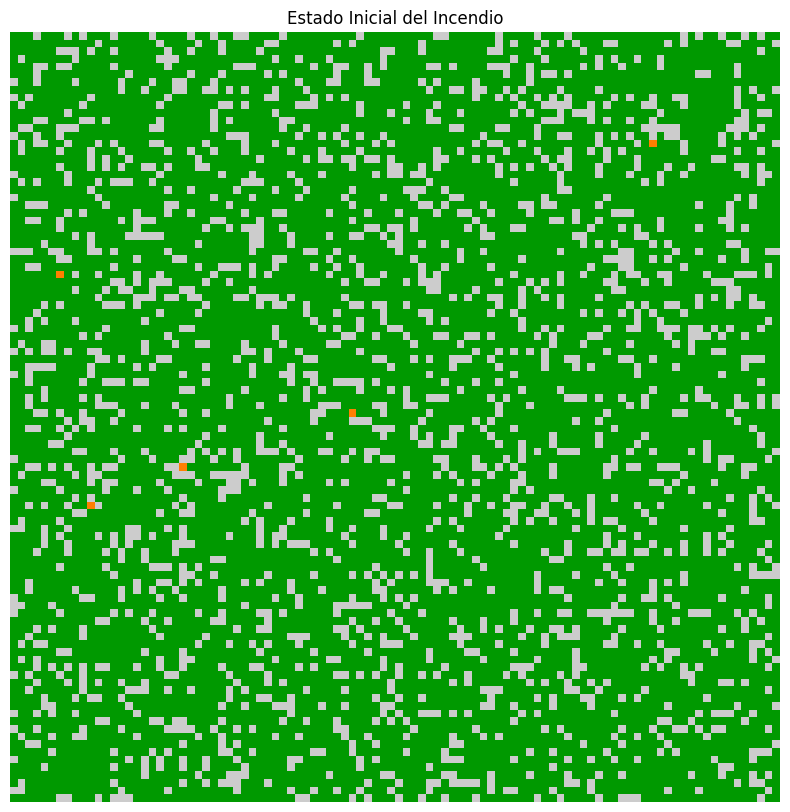

In [4]:
def visualizar_reticulo(reticulo, titulo="Incendio Forestal - Autómata Celular"):
    """
    Muestra el retículo con colores según el estado
    """
    # Crear matriz de colores
    visual = np.zeros((reticulo.shape[0], reticulo.shape[1], 3))

    for i in range(reticulo.shape[0]):
        for j in range(reticulo.shape[1]):
            if reticulo[i, j] == VEGETACION:
                visual[i, j] = [0, 0.6, 0]      # Verde oscuro
            elif reticulo[i, j] == QUEMANDOSE:
                visual[i, j] = [1, 0.5, 0]      # Naranja
            elif reticulo[i, j] == QUEMADO:
                visual[i, j] = [0.2, 0.2, 0.2]  # Gris oscuro
            else:  # VACIO
                visual[i, j] = [0.8, 0.8, 0.8]  # Gris claro

    plt.figure(figsize=(10, 10))
    plt.imshow(visual, interpolation='nearest')
    plt.title(titulo)
    plt.axis('off')
    plt.show()

# Visualizar estado inicial
visualizar_reticulo(reticulo, "Estado Inicial del Incendio")

In [5]:
def obtener_vecinos_con_viento(reticulo, i, j, params):
    """
    Obtiene los vecinos considerando la dirección del viento
    """
    vecinos = []
    filas, cols = reticulo.shape

    # Direcciones: (di, dj)
    direcciones = {
        'N': [(-1, 0)],
        'S': [(1, 0)],
        'E': [(0, 1)],
        'O': [(0, -1)],
        'NE': [(-1, 1)],
        'NO': [(-1, -1)],
        'SE': [(1, 1)],
        'SO': [(1, -1)],
        None: [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    }

    # Obtener dirección del viento
    dir_viento = params.direccion_viento

    # Si hay viento, priorizar esa dirección
    if dir_viento in direcciones:
        vecinos_dir = direcciones[dir_viento]
        # También incluir las direcciones adyacentes (con menor peso)
        vecinos_dir.extend([(0,1), (0,-1), (1,0), (-1,0)])  # Básicas

    # También incluir vecindad completa de Moore
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            ni = (i + di) % filas
            nj = (j + dj) % cols
            vecinos.append((ni, nj, reticulo[ni, nj], di, dj))

    return vecinos

In [6]:
def aplicar_reglas(reticulo, params):
    """
    Aplica las reglas del AC para un paso de tiempo
    """
    filas, cols = reticulo.shape
    nuevo_reticulo = reticulo.copy()

    # Matriz para contar el tiempo que lleva quemándose
    tiempo_quemando = np.zeros_like(reticulo, dtype=int)

    # Actualización paralela (todas las celdas simultáneamente)
    for i in range(filas):
        for j in range(cols):
            estado = reticulo[i, j]

            # REGLA 1: Si está quemándose, avanza en el tiempo de combustión
            if estado == QUEMANDOSE:
                # Incrementar contador (usando una matriz auxiliar)
                # Nota: esto es simplificado, normalmente se lleva un contador aparte
                if np.random.random() < 0.5:  # Simulación de duración variable
                    nuevo_reticulo[i, j] = QUEMADO

            # REGLA 2: Si está verde y tiene vecinos quemándose
            elif estado == VEGETACION:
                # Obtener vecinos
                vecinos = obtener_vecinos_con_viento(reticulo, i, j, params)

                # Contar vecinos en llamas
                vecinos_quemando = 0
                peso_viento = 1.0

                for ni, nj, estado_vecino, di, dj in vecinos:
                    if estado_vecino == QUEMANDOSE:
                        # Peso según dirección del viento
                        if params.direccion_viento == 'E' and dj > 0:
                            peso = 2.0  # Viento a favor
                        elif params.direccion_viento == 'E' and dj < 0:
                            peso = 0.5  # Contra el viento
                        else:
                            peso = 1.0

                        vecinos_quemando += peso

                # Probabilidad de ignición
                if vecinos_quemando > 0:
                    # Base + efecto de humedad
                    p_ignicion = params.p_ignicion_base * (1 - params.humedad)
                    p_ignicion = min(1.0, p_ignicion * vecinos_quemando)

                    # Un poco de aleatoriedad
                    if np.random.random() < p_ignicion:
                        nuevo_reticulo[i, j] = QUEMANDOSE

            # REGLA 3: Ignición espontánea (rayos)
            elif estado == VEGETACION:
                if np.random.random() < params.p_ignicion_espontanea:
                    nuevo_reticulo[i, j] = QUEMANDOSE

            # REGLA 4: El quemado y vacío permanecen igual
            # (no se necesita hacer nada)

    return nuevo_reticulo

In [7]:
def simular_incendio(params, num_pasos=100, mostrar_cada=5):
    """
    Ejecuta la simulación completa
    """
    # Crear retículo inicial
    reticulo = crear_reticulo(params)

    # Historial de estadísticas
    historico = {
        'vegetacion': [np.sum(reticulo == VEGETACION)],
        'quemando': [np.sum(reticulo == QUEMANDOSE)],
        'quemado': [np.sum(reticulo == QUEMADO)],
        'vacio': [np.sum(reticulo == VACIO)]
    }

    # Visualizar estado inicial
    visualizar_reticulo(reticulo, f"Ciclo 0")
    print(f"Ciclo 0 - Vegetación: {historico['vegetacion'][0]}")
    print(f"Quemándose: {historico['quemando'][0]}")
    print(f"Quemado: {historico['quemado'][0]}")
    print(f"Vacío: {historico['vacio'][0]}")
    print("-" * 50)

    # Bucle principal
    for paso in range(1, num_pasos + 1):
        # Aplicar reglas
        reticulo = aplicar_reglas(reticulo, params)

        # Registrar estadísticas
        historico['vegetacion'].append(np.sum(reticulo == VEGETACION))
        historico['quemando'].append(np.sum(reticulo == QUEMANDOSE))
        historico['quemado'].append(np.sum(reticulo == QUEMADO))
        historico['vacio'].append(np.sum(reticulo == VACIO))

        # Mostrar cada cierto número de pasos
        if paso % mostrar_cada == 0:
            clear_output(wait=True)
            visualizar_reticulo(reticulo, f"Ciclo {paso}")
            print(f"Ciclo {paso}")
            print(f"  Vegetación: {historico['vegetacion'][-1]}")
            print(f"  Quemándose: {historico['quemando'][-1]}")
            print(f"  Quemado: {historico['quemado'][-1]}")
            print(f"  Vacío: {historico['vacio'][-1]}")

            # Verificar si se extinguió
            if historico['quemando'][-1] == 0:
                print("🔥 INCENDIO EXTINGUIDO!")
                break

        # Pequeña pausa para visualización
        time.sleep(0.1)

    # Mostrar estadísticas finales
    graficar_estadisticas(historico)

    return reticulo, historico

In [8]:
def graficar_estadisticas(historico):
    """
    Grafica la evolución de los estados
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfico 1: Evolución de estados
    pasos = range(len(historico['vegetacion']))
    ax1.plot(pasos, historico['vegetacion'], 'g-', label='Vegetación', linewidth=2)
    ax1.plot(pasos, historico['quemando'], 'orange', label='Quemándose', linewidth=2)
    ax1.plot(pasos, historico['quemado'], 'k-', label='Quemado', linewidth=2)
    ax1.plot(pasos, historico['vacio'], 'gray', label='Vacío', linewidth=2)
    ax1.set_xlabel('Ciclo')
    ax1.set_ylabel('Número de celdas')
    ax1.set_title('Evolución del Incendio')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Gráfico 2: Área quemada acumulada
    area_quemada = np.array(historico['quemado']) + np.array(historico['vacio']) - historico['vacio'][0]
    ax2.plot(pasos, area_quemada, 'r-', linewidth=2)
    ax2.set_xlabel('Ciclo')
    ax2.set_ylabel('Área quemada acumulada')
    ax2.set_title('Progresión del Área Quemada')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Resumen estadístico
    print("\n" + "="*50)
    print("RESUMEN DE LA SIMULACIÓN")
    print("="*50)
    print(f"Total de celdas: {len(historico['vegetacion'][0])}")
    print(f"Ciclos simulados: {len(historico['vegetacion'])}")
    print(f"Pico de incendio: {max(historico['quemando'])} celdas")
    print(f"Área total quemada: {area_quemada[-1]} celdas")
    print(f"Porcentaje quemado: {area_quemada[-1]/len(historico['vegetacion'])*100:.1f}%")
    print(f"Vegetación sobreviviente: {historico['vegetacion'][-1]} celdas")

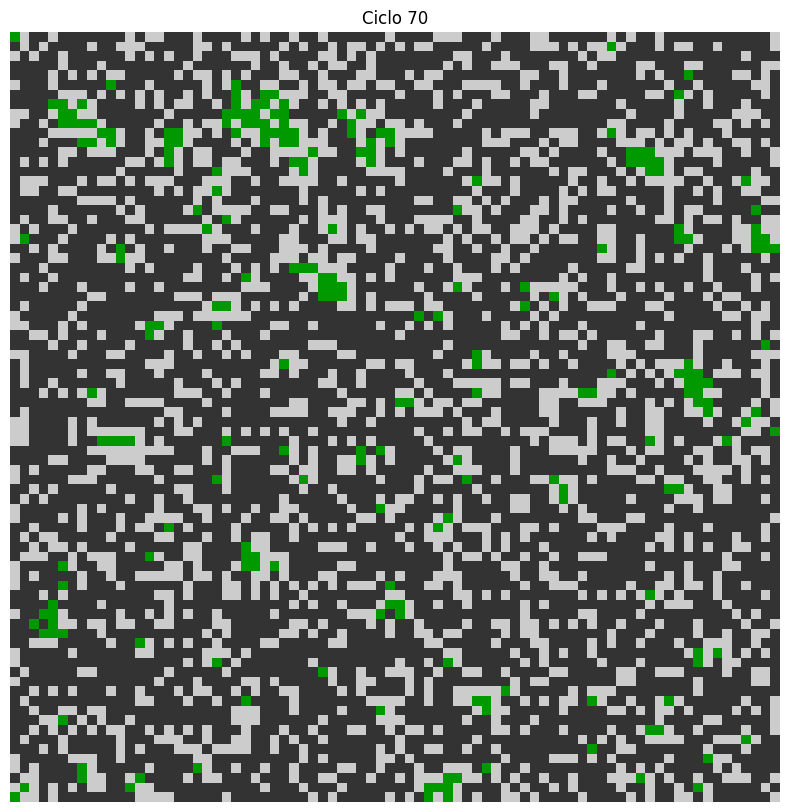

Ciclo 70
  Vegetación: 235
  Quemándose: 0
  Quemado: 4221
  Vacío: 1944
🔥 INCENDIO EXTINGUIDO!


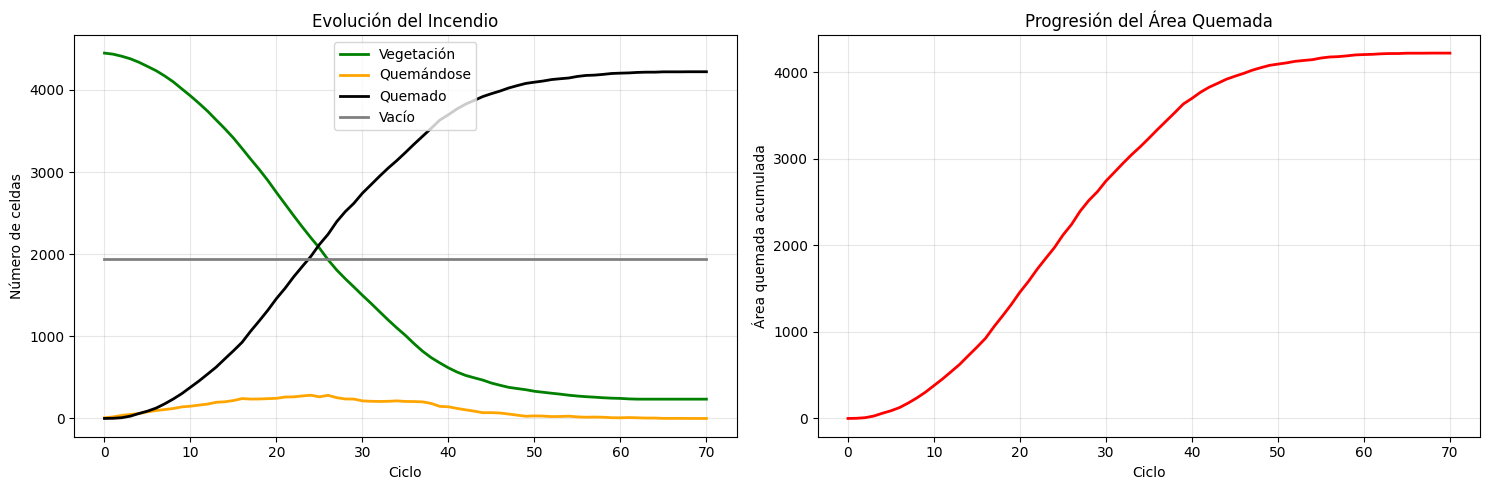


RESUMEN DE LA SIMULACIÓN


TypeError: object of type 'numpy.int64' has no len()

In [11]:
# Configurar parámetros
param = Parametros()
param.filas = 80
param.columnas = 80
param.densidad_vegetacion = 0.7
param.p_ignicion_base = 0.3
param.humedad = 0.1  # Seco
param.direccion_viento = 'E'
param.num_focos = 8

# Ejecutar simulación
reticulo_final, historico = simular_incendio(
    params=param,
    num_pasos=80,
    mostrar_cada=5
)

print("¡Simulación completada!")